# Comparison of the Effect of the Two-Hop Filter and change of thread

This notebook evaluates the effect of adding the proposed **two-hop neighbourhood lower-bound filter** (`d_path`) to the Myopic MCES filtering cascade.

The main comparison is:

- **Baseline:** `d1 → d2 → ILP`
- **Proposed:** `d1 → d2 → d_path → ILP`



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path


# ---------------------------------------------------------
# File paths
# ---------------------------------------------------------
DATA_DIR = Path('../../example/filter and thread comparaison')
cplex_1_file = DATA_DIR /f"filtered_pairs_800_1000_CPLEX_PY_threads_1_comparaison_no_filter.csv"
cplex_8_file = DATA_DIR /f"filtered_pairs_800_1000_CPLEX_PY_threads_8_comparaison_with_filter.csv"

highs_1_file = DATA_DIR /f"filtered_pairs_800_1000_HiGHS_CMD_threads_1_comparaison_no_filter.csv"
highs_8_file = DATA_DIR /f"filtered_pairs_800_1000_HiGHS_CMD_threads_8_comparaison_with_filter.csv"

default_1_file = r"C:\Users\HP\Desktop\thesis\script\example\filter and thread comparaison\filtered_pairs_800_1000_default_threads_1_comparaison_no_filter.csv"

# ---------------------------------------------------------
# Load CSV files
# ---------------------------------------------------------

cplex_1 = pd.read_csv(cplex_1_file)
cplex_8 = pd.read_csv(cplex_8_file)

highs_1 = pd.read_csv(highs_1_file)
highs_8 = pd.read_csv(highs_8_file)

default_1 = pd.read_csv(default_1_file)

# ---------------------------------------------------------
# Check dataset sizes
# ---------------------------------------------------------

print("CPLEX - 1 thread, original filters:", cplex_1.shape)
print("CPLEX - 8 threads, improved filters:", cplex_8.shape)

print("HiGHS - 1 thread, original filters:", highs_1.shape)
print("HiGHS - 8 threads, improved filters:", highs_8.shape)


CPLEX - 1 thread, original filters: (139, 24)
CPLEX - 8 threads, improved filters: (139, 24)
HiGHS - 1 thread, original filters: (139, 24)
HiGHS - 8 threads, improved filters: (139, 24)


In [2]:
experiments = {
    "PULP_CBC - Original": default_1,
    "CPLEX - Original (1 thread)": cplex_1,
    "CPLEX - Improved (8 threads)": cplex_8,
    "HiGHS - Original (1 thread)": highs_1,
    "HiGHS - Improved (8 threads)": highs_8
}


## Comparaison Summary

In [3]:
summary_rows = []

for name, df in experiments.items():

    total_pairs = len(df)

    solver_calls = (df["solverCalled"] == 1).sum()
    solver_not_called = total_pairs - solver_calls

    solver_call_percentage = (
        solver_calls / total_pairs * 100
    )

    total_runtime = df["runtime_sec"].sum()
    mean_runtime = df["runtime_sec"].mean()
    median_runtime = df["runtime_sec"].median()

    timeouts = (
        df["error_message"]
        .fillna("")
        .str.contains("Exceeded", case=False)
        .sum()
    )

    summary_rows.append({
        "Configuration": name,
        "Total Pairs": total_pairs,
        "Solver Calls": solver_calls,
        "Solver Not Called": solver_not_called,
        "Solver Call %": solver_call_percentage,
        "Total Runtime (s)": total_runtime,
        "Mean Runtime (s)": mean_runtime,
        "Median Runtime (s)": median_runtime,
        "Timeouts": timeouts
    })


summary = pd.DataFrame(summary_rows)

summary.round(2)

,Configuration,Total Pairs,Solver Calls,Solver Not Called,Solver Call %,Total Runtime (s),Mean Runtime (s),Median Runtime (s),Timeouts
0,PULP_CBC - Original,139,27,112,19.42,3791.41,27.28,13.84,45
1,CPLEX - Original (1 thread),139,70,69,50.36,1491.79,10.73,3.82,2
2,CPLEX - Improved (8 threads),139,64,75,46.04,680.95,4.90,1.65,1
3,HiGHS - Original (1 thread),139,45,94,32.37,2451.35,17.64,4.70,27
4,HiGHS - Improved (8 threads),139,44,95,31.65,2188.82,15.75,1.64,21


In [4]:
def is_timeout(df):
    return (
        df["error_message"]
        .fillna("")
        .str.contains("Exceeded", case=False)
    )


highs_1_timeouts = highs_1[is_timeout(highs_1)].copy()
highs_8_timeouts = highs_8[is_timeout(highs_8)].copy()

print("HiGHS Original timeouts:", len(highs_1_timeouts))
print("HiGHS Improved timeouts:", len(highs_8_timeouts))

HiGHS Original timeouts: 27
HiGHS Improved timeouts: 21


In [5]:
original_timeout_ids = set(highs_1_timeouts["pair_id"])
improved_timeout_ids = set(highs_8_timeouts["pair_id"])


# Timed out originally, but not anymore
resolved_timeouts = original_timeout_ids - improved_timeout_ids

# Still timeout in both configurations
still_timeouts = original_timeout_ids & improved_timeout_ids

# New timeout only in improved configuration
new_timeouts = improved_timeout_ids - original_timeout_ids


print("Resolved timeouts:", len(resolved_timeouts))
print("Still timeouts:", len(still_timeouts))
print("New timeouts:", len(new_timeouts))

print("\nResolved pair IDs:")
print(sorted(resolved_timeouts))

print("\nNew timeout pair IDs:")
print(sorted(new_timeouts))

Resolved timeouts: 6
Still timeouts: 21
New timeouts: 0

Resolved pair IDs:
[7023, 25314, 27110, 65156, 87904, 107574]

New timeout pair IDs:
[]


In [6]:
resolved_comparison = highs_1[
    highs_1["pair_id"].isin(resolved_timeouts)
][
    [
        "pair_id",
        "runtime_sec",
        "solverCalled",
        "skipped",
        "d1",
        "d2",
        "d_path",
        "distance"
    ]
].merge(
    highs_8[
        highs_8["pair_id"].isin(resolved_timeouts)
    ][
        [
            "pair_id",
            "runtime_sec",
            "solverCalled",
            "skipped",
            "d1",
            "d2",
            "d_path",
            "distance"
        ]
    ],
    on="pair_id",
    suffixes=("_original", "")
)

resolved_comparison

,pair_id,runtime_sec_original,solverCalled_original,skipped_original,d1_original,d2_original,d_path_original,distance_original,runtime_sec,solverCalled,skipped,d1,d2,d_path,distance
0,7023,60.0,0,1,NaN,NaN,NaN,NaN,49.183336,1,0,0.0,0.0,1.0,6.0
1,25314,60.0,0,1,NaN,NaN,NaN,NaN,50.651910,1,0,1.0,1.0,2.0,6.0
2,27110,60.0,0,1,NaN,NaN,NaN,NaN,59.486920,1,0,1.0,1.0,2.5,6.0
3,65156,60.0,0,1,NaN,NaN,NaN,NaN,53.118155,1,0,0.0,0.0,1.0,6.0
4,87904,60.0,0,1,NaN,NaN,NaN,NaN,49.707485,1,0,1.0,1.0,2.0,6.0
5,107574,60.0,0,1,NaN,NaN,NaN,NaN,52.831017,1,0,0.0,0.0,1.0,4.0


In [7]:
thesis_summary = summary[
    [
        "Configuration",
        "Total Pairs",
        "Solver Calls",
        "Total Runtime (s)",
        "Mean Runtime (s)",
        "Timeouts"
    ]
].copy()

thesis_summary.round(2)

,Configuration,Total Pairs,Solver Calls,Total Runtime (s),Mean Runtime (s),Timeouts
0,PULP_CBC - Original,139,27,3791.41,27.28,45
1,CPLEX - Original (1 thread),139,70,1491.79,10.73,2
2,CPLEX - Improved (8 threads),139,64,680.95,4.90,1
3,HiGHS - Original (1 thread),139,45,2451.35,17.64,27
4,HiGHS - Improved (8 threads),139,44,2188.82,15.75,21


In [8]:
solver_call_comparison = pd.DataFrame({
    "Solver": ["CPLEX", "HiGHS"],

    "Original Solver Calls": [
        (cplex_1["solverCalled"] == 1).sum(),
        (highs_1["solverCalled"] == 1).sum()
    ],

    "Improved Solver Calls": [
        (cplex_8["solverCalled"] == 1).sum(),
        (highs_8["solverCalled"] == 1).sum()
    ]
})

solver_call_comparison


,Solver,Original Solver Calls,Improved Solver Calls
0,CPLEX,70,64
1,HiGHS,45,44


In [9]:
solver_call_comparison["Calls Avoided"] = (
    solver_call_comparison["Original Solver Calls"]
    -
    solver_call_comparison["Improved Solver Calls"]
)

solver_call_comparison["Reduction (%)"] = (
    solver_call_comparison["Calls Avoided"]
    /
    solver_call_comparison["Original Solver Calls"]
    * 100
)

solver_call_comparison.round(2)

,Solver,Original Solver Calls,Improved Solver Calls,Calls Avoided,Reduction (%)
0,CPLEX,70,64,6,8.57
1,HiGHS,45,44,1,2.22


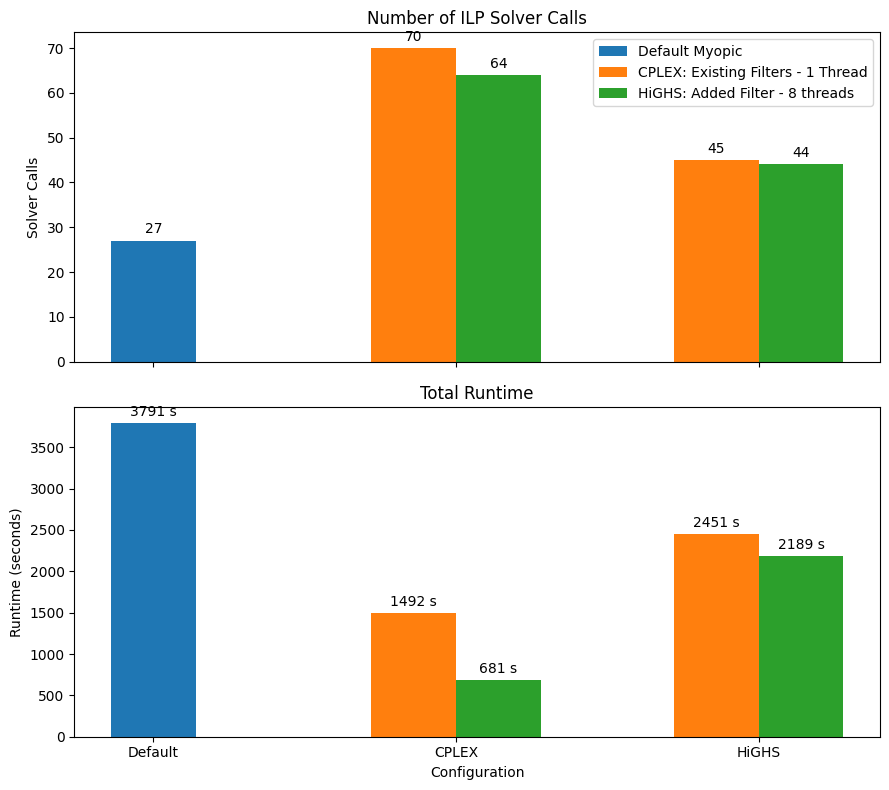

In [11]:
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# Values
# ---------------------------------------------------------

default_calls = (default_1["solverCalled"] == 1).sum()
cplex_original_calls = (cplex_1["solverCalled"] == 1).sum()
cplex_improved_calls = (cplex_8["solverCalled"] == 1).sum()
highs_original_calls = (highs_1["solverCalled"] == 1).sum()
highs_improved_calls = (highs_8["solverCalled"] == 1).sum()

default_runtime = default_1["runtime_sec"].sum()
cplex_original_runtime = cplex_1["runtime_sec"].sum()
cplex_improved_runtime = cplex_8["runtime_sec"].sum()
highs_original_runtime = highs_1["runtime_sec"].sum()
highs_improved_runtime = highs_8["runtime_sec"].sum()


# ---------------------------------------------------------
# Positions
# ---------------------------------------------------------

groups = ["Default", "CPLEX", "HiGHS"]

x = np.arange(len(groups))
width = 0.28


# ---------------------------------------------------------
# Create figure
# ---------------------------------------------------------

fig, (ax1, ax2) = plt.subplots(
    2,
    1,
    figsize=(9, 8),
    sharex=True
)


# =========================================================
# 1. SOLVER CALLS
# =========================================================

default_bar = ax1.bar(
    x[0],
    default_calls,
    width,
    label="Default Myopic"
)

original_bars = ax1.bar(
    [x[1] - width / 2, x[2] - width / 2],
    [cplex_original_calls, highs_original_calls],
    width,
    label="CPLEX: Existing Filters - 1 Thread"
)

improved_bars = ax1.bar(
    [x[1] + width / 2, x[2] + width / 2],
    [cplex_improved_calls, highs_improved_calls],
    width,
    label="HiGHS: Added Filter - 8 threads"
)

ax1.set_title("Number of ILP Solver Calls")
ax1.set_ylabel("Solver Calls")

ax1.bar_label(default_bar, padding=3)
ax1.bar_label(original_bars, padding=3)
ax1.bar_label(improved_bars, padding=3)

ax1.legend()


# =========================================================
# 2. TOTAL RUNTIME
# =========================================================

default_runtime_bar = ax2.bar(
    x[0],
    default_runtime,
    width
)

original_runtime_bars = ax2.bar(
    [x[1] - width / 2, x[2] - width / 2],
    [
        cplex_original_runtime,
        highs_original_runtime
    ],
    width
)

improved_runtime_bars = ax2.bar(
    [x[1] + width / 2, x[2] + width / 2],
    [
        cplex_improved_runtime,
        highs_improved_runtime
    ],
    width
)

ax2.set_title("Total Runtime")
ax2.set_ylabel("Runtime (seconds)")
ax2.set_xlabel("Configuration")

ax2.set_xticks(x)
ax2.set_xticklabels(groups)


# Runtime labels
ax2.bar_label(
    default_runtime_bar,
    fmt="%.0f s",
    padding=3
)

ax2.bar_label(
    original_runtime_bars,
    fmt="%.0f s",
    padding=3
)

ax2.bar_label(
    improved_runtime_bars,
    fmt="%.0f s",
    padding=3
)


# ---------------------------------------------------------
# Final layout
# ---------------------------------------------------------

plt.tight_layout()
plt.show()

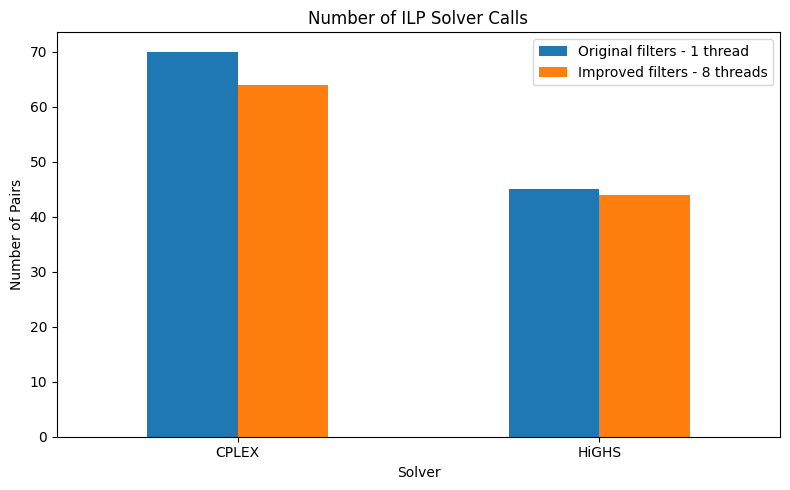

In [19]:
plot_data = solver_call_comparison.set_index("Solver")[
    [
        "Original Solver Calls",
        "Improved Solver Calls"
    ]
]

ax = plot_data.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Number of ILP Solver Calls")
plt.xlabel("Solver")
plt.ylabel("Number of Pairs")
plt.xticks(rotation=0)
plt.legend(["Original filters - 1 thread",
            "Improved filters - 8 threads"])

plt.tight_layout()
plt.show()

## Runtime

In [20]:
runtime_comparison = pd.DataFrame({
    "Solver": ["CPLEX", "HiGHS"],

    "Original Runtime": [
        cplex_1["runtime_sec"].sum(),
        highs_1["runtime_sec"].sum()
    ],

    "Improved Runtime": [
        cplex_8["runtime_sec"].sum(),
        highs_8["runtime_sec"].sum()
    ]
})

runtime_comparison


,Solver,Original Runtime,Improved Runtime
0,CPLEX,1491.787,680.951
1,HiGHS,2451.353,2188.818


In [21]:
runtime_comparison["Time Saved (s)"] = (
    runtime_comparison["Original Runtime"]
    -
    runtime_comparison["Improved Runtime"]
)

runtime_comparison["Runtime Reduction (%)"] = (
    runtime_comparison["Time Saved (s)"]
    /
    runtime_comparison["Original Runtime"]
    * 100
)

runtime_comparison["Speedup"] = (
    runtime_comparison["Original Runtime"]
    /
    runtime_comparison["Improved Runtime"]
)

runtime_comparison.round(2)


,Solver,Original Runtime,Improved Runtime,Time Saved (s),Runtime Reduction (%),Speedup
0,CPLEX,1491.790,680.950,810.840,54.350,2.190
1,HiGHS,2451.350,2188.820,262.540,10.710,1.120


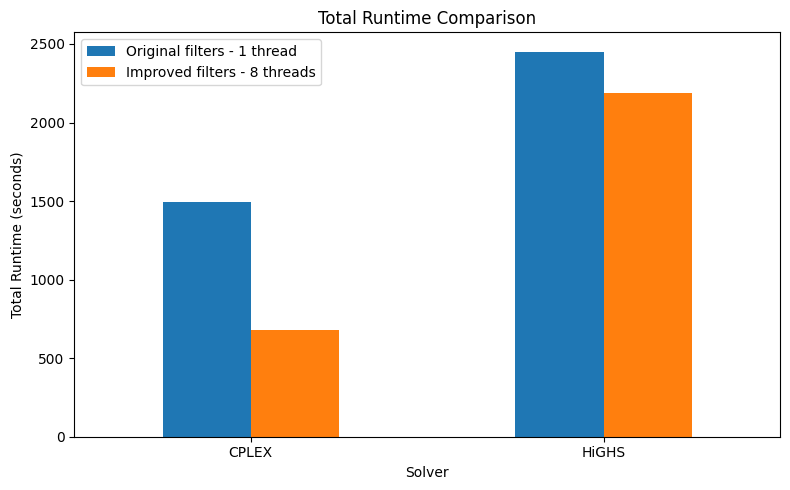

In [22]:
plot_runtime = runtime_comparison.set_index("Solver")[
    [
        "Original Runtime",
        "Improved Runtime"
    ]
]

ax = plot_runtime.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Total Runtime Comparison")
plt.xlabel("Solver")
plt.ylabel("Total Runtime (seconds)")
plt.xticks(rotation=0)

plt.legend([
    "Original filters - 1 thread",
    "Improved filters - 8 threads"
])

plt.tight_layout()
plt.show()

In [23]:
cplex_pairs = cplex_1[
    [
        "pair_id",
        "runtime_sec",
        "solverCalled"
    ]
].merge(
    cplex_8[
        [
            "pair_id",
            "runtime_sec",
            "solverCalled"
        ]
    ],
    on="pair_id",
    suffixes=("_original", "_improved")
)

cplex_pairs.head()

,pair_id,runtime_sec_original,solverCalled_original,runtime_sec_improved,solverCalled_improved
0,964,3.639,1,1.648,0
1,1073,41.909,1,15.875,1
2,1586,1.624,0,1.217,0
3,3772,1.620,0,1.211,0
4,3995,1.526,0,1.277,0


In [24]:
cplex_pairs["speedup"] = (
    cplex_pairs["runtime_sec_original"]
    /
    cplex_pairs["runtime_sec_improved"]
)

cplex_pairs["time_saved"] = (
    cplex_pairs["runtime_sec_original"]
    -
    cplex_pairs["runtime_sec_improved"]
)

cplex_pairs.head()

,pair_id,runtime_sec_original,solverCalled_original,runtime_sec_improved,solverCalled_improved,speedup,time_saved
0,964,3.639,1,1.648,0,2.209,1.991
1,1073,41.909,1,15.875,1,2.640,26.034
2,1586,1.624,0,1.217,0,1.334,0.407
3,3772,1.620,0,1.211,0,1.338,0.409
4,3995,1.526,0,1.277,0,1.196,0.250


In [25]:
print(
    "Pairs faster with improved configuration:",
    (cplex_pairs["speedup"] > 1).sum()
)

print(
    "Pairs slower with improved configuration:",
    (cplex_pairs["speedup"] < 1).sum()
)

print(
    "Median speedup:",
    round(cplex_pairs["speedup"].median(), 2)
)

print(
    "Mean speedup:",
    round(cplex_pairs["speedup"].mean(), 2)
)

Pairs faster with improved configuration: 132
Pairs slower with improved configuration: 6
Median speedup: 1.97
Mean speedup: 2.26


In [26]:
print(
    "Pairs faster with improved configuration:",
    (cplex_pairs["speedup"] > 1).sum()
)

print(
    "Pairs slower with improved configuration:",
    (cplex_pairs["speedup"] < 1).sum()
)

print(
    "Median speedup:",
    round(cplex_pairs["speedup"].median(), 2)
)

print(
    "Mean speedup:",
    round(cplex_pairs["speedup"].mean(), 2)
)

Pairs faster with improved configuration: 132
Pairs slower with improved configuration: 6
Median speedup: 1.97
Mean speedup: 2.26


In [27]:
print(
    "Pairs faster with improved configuration:",
    (cplex_pairs["speedup"] > 1).sum()
)

print(
    "Pairs slower with improved configuration:",
    (cplex_pairs["speedup"] < 1).sum()
)

print(
    "Median speedup:",
    round(cplex_pairs["speedup"].median(), 2)
)

print(
    "Mean speedup:",
    round(cplex_pairs["speedup"].mean(), 2)
)

Pairs faster with improved configuration: 132
Pairs slower with improved configuration: 6
Median speedup: 1.97
Mean speedup: 2.26


In [29]:
highs_pairs = highs_1[
    [
        "pair_id",
        "runtime_sec",
        "solverCalled"
    ]
].merge(
    highs_8[
        [
            "pair_id",
            "runtime_sec",
            "solverCalled"
        ]
    ],
    on="pair_id",
    suffixes=("_original", "_improved")
)

highs_pairs["speedup"] = (
    highs_pairs["runtime_sec_original"]
    /
    highs_pairs["runtime_sec_improved"]
)

highs_pairs["time_saved"] = (
    highs_pairs["runtime_sec_original"]
    -
    highs_pairs["runtime_sec_improved"]
)

highs_pairs.head()

,pair_id,runtime_sec_original,solverCalled_original,runtime_sec_improved,solverCalled_improved,speedup,time_saved
0,964,6.945,1,1.641,0,4.232,5.304
1,1073,60.000,0,60.000,0,1.000,0.000
2,1586,1.915,0,1.141,0,1.679,0.775
3,3772,1.480,0,1.295,0,1.143,0.185
4,3995,1.429,0,1.194,0,1.196,0.235


In [30]:
print(
    "Pairs faster with improved configuration:",
    (highs_pairs["speedup"] > 1).sum()
)

print(
    "Pairs slower with improved configuration:",
    (highs_pairs["speedup"] < 1).sum()
)

print(
    "Median speedup:",
    round(highs_pairs["speedup"].median(), 2)
)

print(
    "Mean speedup:",
    round(highs_pairs["speedup"].mean(), 2)
)

Pairs faster with improved configuration: 112
Pairs slower with improved configuration: 6
Median speedup: 1.27
Mean speedup: 1.59


In [31]:
cplex_avoided = cplex_pairs[
    (cplex_pairs["solverCalled_original"] == 1)
    &
    (cplex_pairs["solverCalled_improved"] == 0)
]

highs_avoided = highs_pairs[
    (highs_pairs["solverCalled_original"] == 1)
    &
    (highs_pairs["solverCalled_improved"] == 0)
]

print(
    "CPLEX solver calls avoided:",
    len(cplex_avoided)
)

print(
    "HiGHS solver calls avoided:",
    len(highs_avoided)
)

CPLEX solver calls avoided: 7
HiGHS solver calls avoided: 7


In [32]:
print("CPLEX")
print(
    "Runtime before:",
    round(cplex_avoided["runtime_sec_original"].sum(), 2)
)

print(
    "Runtime after:",
    round(cplex_avoided["runtime_sec_improved"].sum(), 2)
)

print(
    "Time saved:",
    round(cplex_avoided["time_saved"].sum(), 2)
)


print("\nHiGHS")
print(
    "Runtime before:",
    round(highs_avoided["runtime_sec_original"].sum(), 2)
)

print(
    "Runtime after:",
    round(highs_avoided["runtime_sec_improved"].sum(), 2)
)

print(
    "Time saved:",
    round(highs_avoided["time_saved"].sum(), 2)
)

CPLEX
Runtime before: 44.73
Runtime after: 12.27
Time saved: 32.46

HiGHS
Runtime before: 71.74
Runtime after: 11.75
Time saved: 59.99
